# 2. Обучение моделей

## 2.1. Импорты и настройка

In [1]:
import os, json, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Создаём папки
os.makedirs('data/processed', exist_ok=True)

## 2.2. Загрузка параметров и данных

In [2]:
with open('params.yaml', 'r') as f:
    params = yaml.safe_load(f)

p = params['model_training']

df = pd.read_csv('data/raw/insurance.csv')

## 2.3. Подготовка признаков и целевой переменной

In [3]:
target = 'charges'

# Кодируем категориальные признаки
cat_cols = ['sex', 'smoker', 'region']
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Разделяем X и y
X = df.drop(target, axis=1)
y = df[target]

# Логарифмируем целевую переменную (по рекомендации EDA)
y_log = np.log1p(y)

## 2.4. Разделение на выборки данных

In [4]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y_log, test_size=p['test_size'], random_state=p['random_state']
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=p['valid_size']/(1-p['test_size']),
    random_state=p['random_state']
)

# Масштабирование числовых признаков (для нейронной сети и линейной регрессии)
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children']
X_train_scaled = X_train.copy()
X_valid_scaled = X_valid.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_valid_scaled[num_cols] = scaler.transform(X_valid[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f'Train size: {X_train.shape[0]}, Valid size: {X_valid.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 870, Valid size: 125, Test size: 249


## 2.5. Словарь для сохранения метрик

In [5]:
all_metrics = {}

## 2.6. Линейная регрессия

In [6]:
print("=== Линейная регрессия ===")
lr_params = p['linear_regression']
lr = LinearRegression(fit_intercept=lr_params['fit_intercept'])
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

all_metrics['linear_regression'] = {
    'MSE': float(mse_lr),
    'MAE': float(mae_lr),
    'R2': float(r2_lr)
}
print(f"Коэффициенты: {dict(zip(X.columns, lr.coef_))}")
print(f"MSE: {mse_lr:.4f}, MAE: {mae_lr:.4f}, R2: {r2_lr:.4f}")

=== Линейная регрессия ===
Коэффициенты: {'age': np.float64(0.4949647728129329), 'sex': np.float64(-0.05635586643893323), 'bmi': np.float64(0.08950919968551832), 'children': np.float64(0.13179650156904552), 'smoker': np.float64(1.5629173733085402), 'region': np.float64(-0.05365328475454615)}
MSE: 0.2284, MAE: 0.2867, R2: 0.7237


## 2.7. Дерево решений


=== Дерево решений ===
MSE: 0.1712, MAE: 0.2309, R2: 0.7928


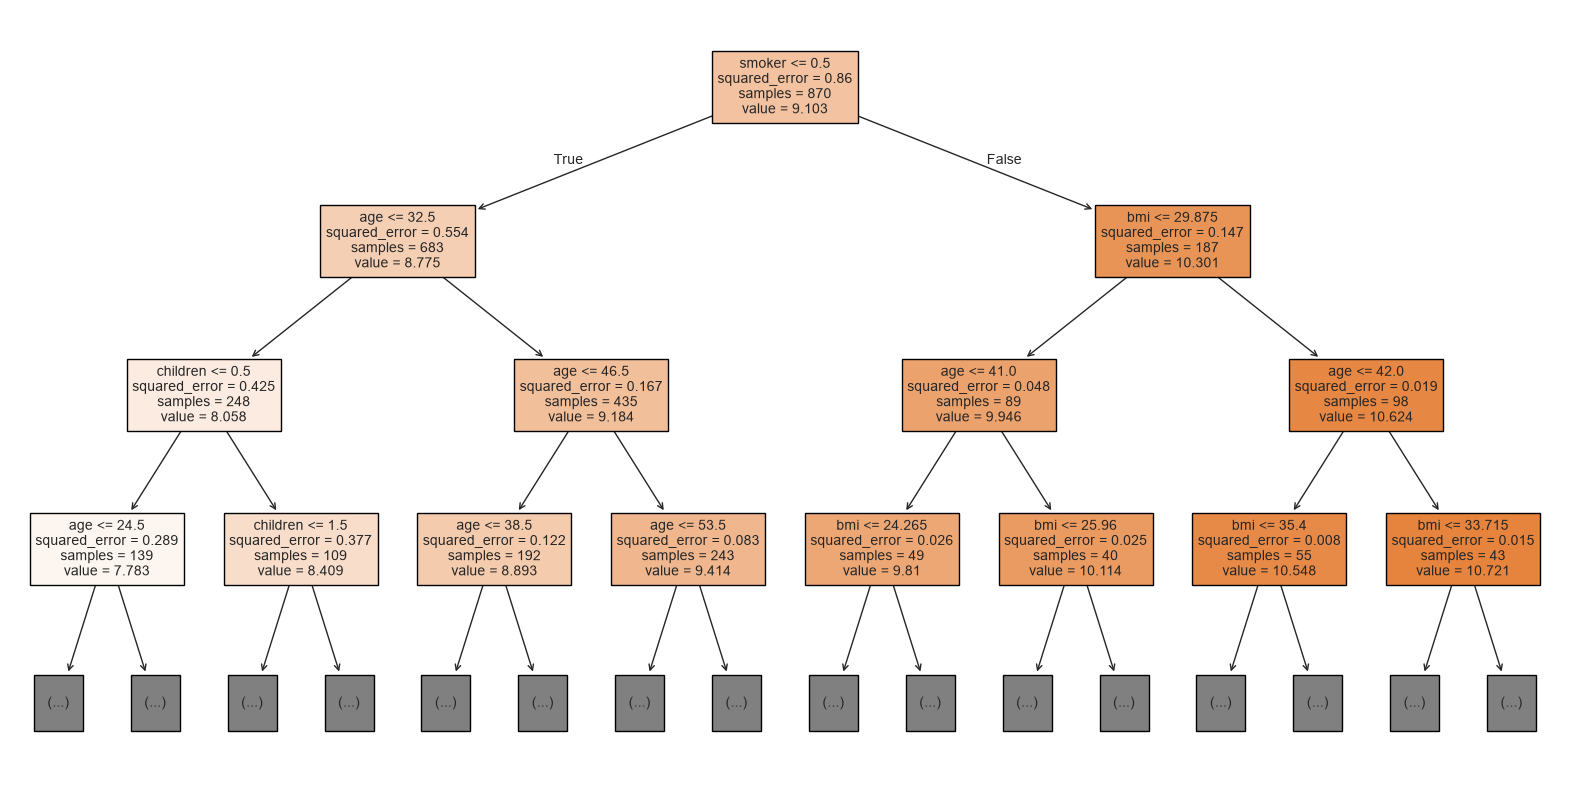

In [7]:
print("\n=== Дерево решений ===")
dt_params = p['decision_tree']
dt = DecisionTreeRegressor(
    max_depth=dt_params['max_depth'],
    min_samples_split=dt_params['min_samples_split'],
    min_samples_leaf=dt_params['min_samples_leaf'],
    random_state=p['random_state']
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

mse_dt = mean_squared_error(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

all_metrics['decision_tree'] = {
    'MSE': float(mse_dt),
    'MAE': float(mae_dt),
    'R2': float(r2_dt)
}
print(f"MSE: {mse_dt:.4f}, MAE: {mae_dt:.4f}, R2: {r2_dt:.4f}")

# Рисунок первых узлов дерева
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, filled=True, max_depth=3, fontsize=10)
plt.savefig('data/processed/decision_tree_first_nodes.png', dpi=150, bbox_inches='tight')
plt.show()

## 2.8. CatBoost


=== CatBoost ===
MSE: 0.1707, MAE: 0.2553, R2: 0.7935


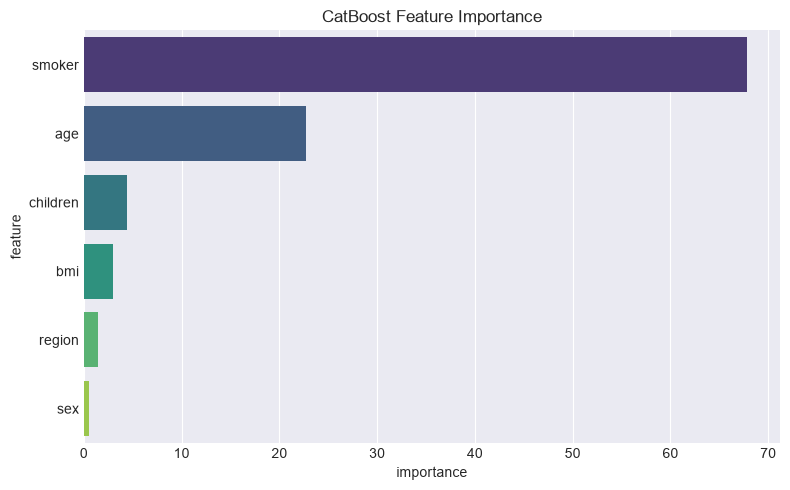

In [8]:
print("\n=== CatBoost ===")
cb_params = p['catboost']
cb = CatBoostRegressor(
    iterations=cb_params['iterations'],
    learning_rate=cb_params['learning_rate'],
    depth=cb_params['depth'],
    verbose=cb_params['verbose'],
    random_seed=p['random_state']
)
cb.fit(X_train, y_train, eval_set=(X_valid, y_valid), early_stopping_rounds=50)

y_pred_cb = cb.predict(X_test)

mse_cb = mean_squared_error(y_test, y_pred_cb)
mae_cb = mean_absolute_error(y_test, y_pred_cb)
r2_cb = r2_score(y_test, y_pred_cb)

all_metrics['catboost'] = {
    'MSE': float(mse_cb),
    'MAE': float(mae_cb),
    'R2': float(r2_cb)
}
print(f"MSE: {mse_cb:.4f}, MAE: {mae_cb:.4f}, R2: {r2_cb:.4f}")

# Feature Importance
plt.figure(figsize=(8,5))
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': cb.feature_importances_
}).sort_values('importance', ascending=False)
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.savefig('data/processed/feature_importance_catboost.png')
plt.show()

## 2.9. XGBoost


=== XGBoost ===
MSE: 0.1711, MAE: 0.2133, R2: 0.7929


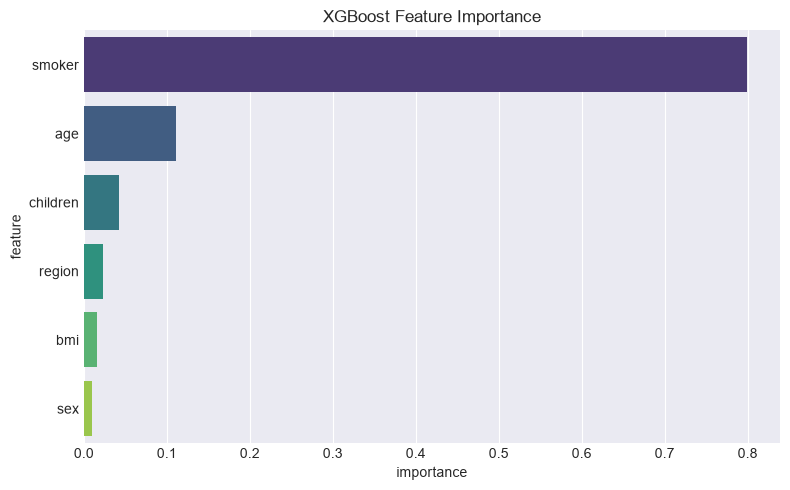

In [9]:
print("\n=== XGBoost ===")
xgb_params = p['xgboost']
xgb = XGBRegressor(
    n_estimators=xgb_params['n_estimators'],
    max_depth=xgb_params['max_depth'],
    learning_rate=xgb_params['learning_rate'],
    verbosity=xgb_params['verbosity'],
    random_state=p['random_state']
)
xgb.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)

y_pred_xgb = xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

all_metrics['xgboost'] = {
    'MSE': float(mse_xgb),
    'MAE': float(mae_xgb),
    'R2': float(r2_xgb)
}
print(f"MSE: {mse_xgb:.4f}, MAE: {mae_xgb:.4f}, R2: {r2_xgb:.4f}")

# Feature Importance
plt.figure(figsize=(8,5))
imp_df_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)
sns.barplot(data=imp_df_xgb, x='importance', y='feature', palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.savefig('data/processed/feature_importance_xgboost.png')
plt.show()

## 2.10. Нейронная сеть


=== Нейронная сеть (Keras) с TensorBoard ===
Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 58.6482 - mae: 7.5257 - val_loss: 28.0583 - val_mae: 5.1621
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 12.8084 - mae: 3.0578 - val_loss: 5.8221 - val_mae: 2.0222
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.1325 - mae: 1.8429 - val_loss: 3.5722 - val_mae: 1.5108
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3348 - mae: 1.4511 - val_loss: 2.8897 - val_mae: 1.3765
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8090 - mae: 1.3207 - val_loss: 2.5688 - val_mae: 1.2839
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4255 - mae: 1.2213 - val_loss: 2.3318 - val_mae: 1.2173
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1297 - mae: 1.1441 - val_loss: 2.0303 - val_mae: 1.1353
Epoch 8/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.8661 - mae: 1.0649 - val_loss: 1.7721 - val_mae: 1.0544
Epoch 9/100
28/

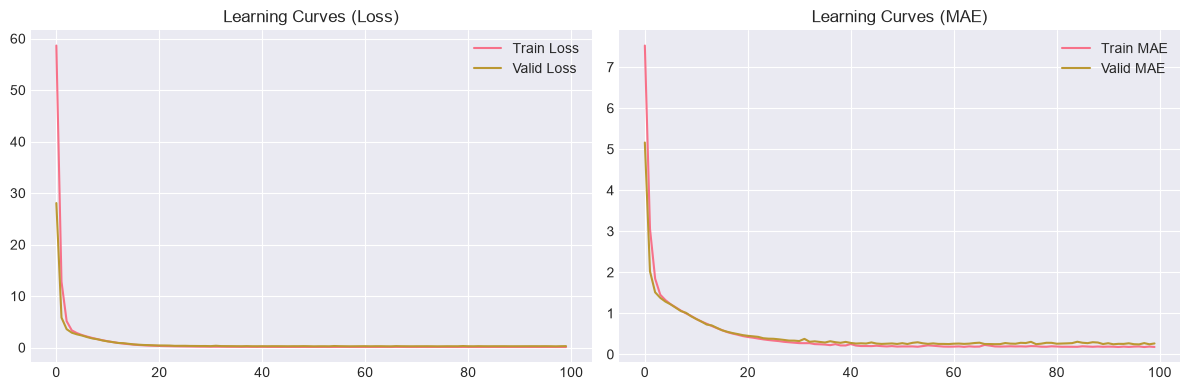

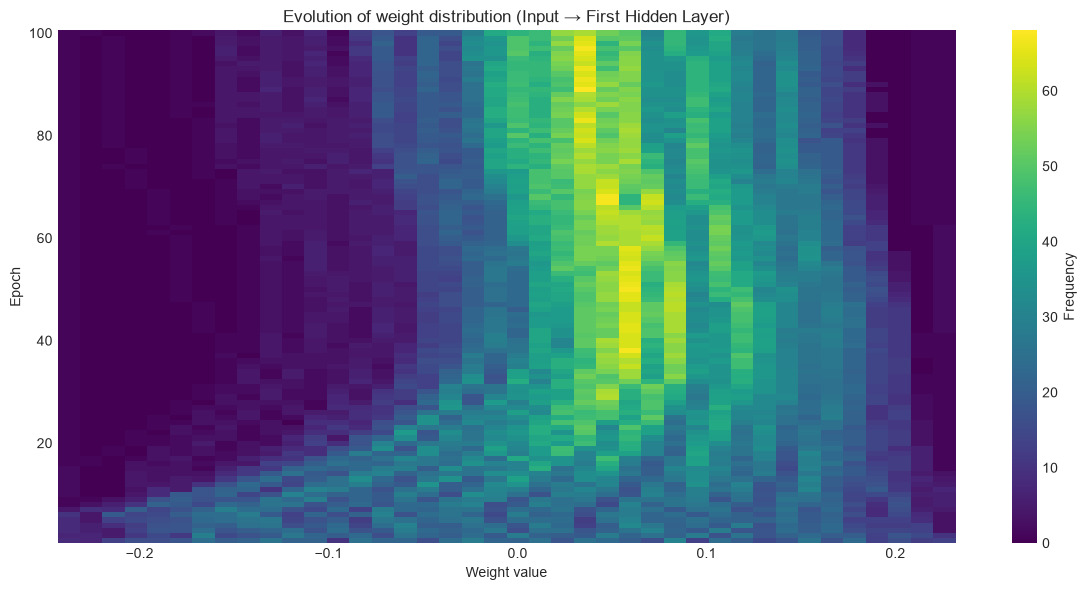

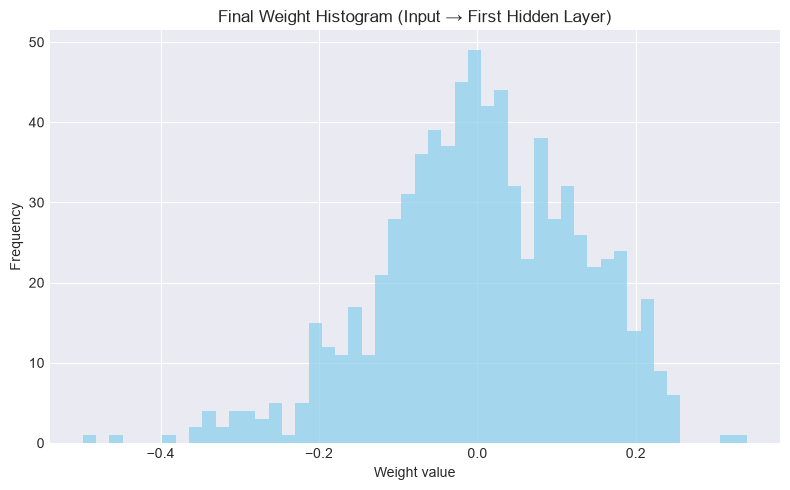

In [16]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n=== Нейронная сеть (Keras) с TensorBoard ===")
nn_params = p['neural_network']

model = keras.Sequential()
model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
for units in nn_params['hidden_units']:
    model.add(layers.Dense(units, activation='relu'))
model.add(layers.Dense(1))   # выходной слой (регрессия)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=nn_params['learning_rate']),
    loss='mse',
    metrics=['mae']
)

# --- Кастомный колбэк для сохранения весов на каждой эпохе ---
class WeightHistory(keras.callbacks.Callback):
    def __init__(self, layer_index=0):
        super().__init__()
        self.layer_index = layer_index
        self.epoch_weights = []   # список массивов весов после каждой эпохи

    def on_epoch_end(self, epoch, logs=None):
        weights = self.model.layers[self.layer_index].get_weights()[0].flatten()
        self.epoch_weights.append(weights.copy())

weight_cb = WeightHistory(layer_index=0)   # сохраняем веса первого скрытого слоя

# Колбэк TensorBoard (для визуализации в реальном времени)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_cb = keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_valid_scaled, y_valid),
    epochs=nn_params['epochs'],
    batch_size=nn_params['batch_size'],
    callbacks=[tensorboard_cb, weight_cb],
    verbose=1
)

y_pred_nn = model.predict(X_test_scaled).flatten()

mse_nn = mean_squared_error(y_test, y_pred_nn)
mae_nn = mean_absolute_error(y_test, y_pred_nn)
r2_nn = r2_score(y_test, y_pred_nn)

all_metrics['neural_network'] = {
    'MSE': float(mse_nn),
    'MAE': float(mae_nn),
    'R2' : float(r2_nn)
}
print(f"MSE: {mse_nn:.4f}, MAE: {mae_nn:.4f}, R2: {r2_nn:.4f}")

# --- Кривые обучения ---
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Valid Loss')
plt.title('Learning Curves (Loss)')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Valid MAE')
plt.title('Learning Curves (MAE)')
plt.legend()
plt.tight_layout()
plt.savefig('data/processed/nn_training_history.png')
plt.show()

# CSV для DVC plots
hist_df = pd.DataFrame(history.history)
hist_df.to_csv('data/processed/nn_training_curves.csv', index=False)

# --- 3D‑визуализация эволюции распределения весов ---
# Для первого скрытого слоя
epochs = range(1, len(weight_cb.epoch_weights)+1)
# Строим гистограммы для всех эпох, объединяя данные в виде тепловой карты
bins = 40
hist_data = []
bin_edges = None
for w in weight_cb.epoch_weights:
    counts, edges = np.histogram(w, bins=bins)
    hist_data.append(counts)
    if bin_edges is None:
        bin_edges = edges
hist_data = np.array(hist_data)   # shape (num_epochs, bins)

# Визуализация в виде pcolormesh
plt.figure(figsize=(12,6))
plt.pcolormesh(bin_edges[:-1], list(epochs), hist_data, shading='auto', cmap='viridis')
plt.colorbar(label='Frequency')
plt.xlabel('Weight value')
plt.ylabel('Epoch')
plt.title('Evolution of weight distribution (Input → First Hidden Layer)')
plt.tight_layout()
plt.savefig('data/processed/nn_weight_evolution.png')
plt.show()

# Альтернативно – итоговая гистограмма весов (как раньше)
plt.figure(figsize=(8,5))
final_weights = weight_cb.epoch_weights[-1]
plt.hist(final_weights, bins=50, alpha=0.7, color='skyblue')
plt.title('Final Weight Histogram (Input → First Hidden Layer)')
plt.xlabel('Weight value')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('data/processed/nn_weight_histograms.png')
plt.show()

## 2.11. Сохранение всех метрик

In [13]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def extract_and_plot(log_dir, output_dir='data/processed'):
    os.makedirs(output_dir, exist_ok=True)
    
    # Находим последнюю папку с логами
    run_dirs = [d for d in os.listdir(log_dir) if os.path.isdir(os.path.join(log_dir, d))]
    if not run_dirs:
        print("Логи TensorBoard не найдены.")
        return
    latest_run = max(run_dirs)  # выбираем последний запуск
    event_path = os.path.join(log_dir, latest_run)
    
    ea = EventAccumulator(event_path)
    ea.Reload()
    
    # --- Кривые обучения (SCALARS) ---
    tags = ea.Tags()['scalars']
    # Ожидаем, что есть 'epoch_loss' и 'epoch_mae' (или с префиксом MLP/...)
    # Подставьте точные имена тегов, которые вы использовали в SummaryWriter
    loss_tag = [t for t in tags if 'train_loss' in t][0] if any('train_loss' in t for t in tags) else None
    mae_tag  = [t for t in tags if 'train_mae' in t][0] if any('train_mae' in t for t in tags) else None
    
    if loss_tag:
        loss_events = ea.Scalars(loss_tag)
        steps = [e.step for e in loss_events]
        values = [e.value for e in loss_events]
        plt.figure(figsize=(8,4))
        plt.plot(steps, values, label='Train Loss')
        # Если есть валидационные метрики, тоже добавляем
        val_loss_tag = loss_tag.replace('train', 'val')
        if val_loss_tag in tags:
            val_events = ea.Scalars(val_loss_tag)
            plt.plot([e.step for e in val_events], [e.value for e in val_events], label='Valid Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'tensorboard_loss.png'))
        plt.show()
    
    if mae_tag:
        mae_events = ea.Scalars(mae_tag)
        steps = [e.step for e in mae_events]
        values = [e.value for e in mae_events]
        plt.figure(figsize=(8,4))
        plt.plot(steps, values, label='Train MAE')
        val_mae_tag = mae_tag.replace('train', 'val')
        if val_mae_tag in tags:
            val_events = ea.Scalars(val_mae_tag)
            plt.plot([e.step for e in val_events], [e.value for e in val_events], label='Valid MAE')
        plt.title('Training and Validation MAE')
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'tensorboard_mae.png'))
        plt.show()
    
    # --- Гистограммы весов (HISTOGRAMS) ---
    # TensorBoard хранит гистограммы как сжатые данные, напрямую их не визуализировать через EventAccumulator.
    # Рекомендуется использовать ранее сохранённый график nn_weight_histograms.png.
    # Здесь можно просто указать, что они доступны в TensorBoard.

# Запуск
extract_and_plot('logs/fit')

In [18]:
import os, numpy as np, matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

logdir = 'logs/fit'
runs = [d for d in os.listdir(logdir) if os.path.isdir(os.path.join(logdir, d))]
if not runs:
    raise FileNotFoundError("Нет подпапок с логами в logs/fit")
latest = max(runs)
event_path = os.path.join(logdir, latest)

ea = EventAccumulator(event_path)
ea.Reload()

# --- SCALARS ---
scalar_tags = ea.Tags()['scalars']
print("Найденные скалярные теги:", scalar_tags)

if not scalar_tags:
    print("Скалярные теги не найдены – проверьте логи TensorBoard.")
else:
    for tag in scalar_tags:
        events = ea.Scalars(tag)
        steps = [e.step for e in events]
        values = [e.value for e in events]
        plt.figure(figsize=(8, 4))
        plt.plot(steps, values)
        plt.title(tag)
        plt.xlabel('Step')
        plt.ylabel(tag)
        plt.tight_layout()
        # сохраняем
        fname = tag.replace('/', '_') + '.png'
        plt.savefig(os.path.join('data/processed', fname))
        plt.show()
        plt.close()   # чтобы не накладывались друг на друга

# --- HISTOGRAMS ---
hist_tags = ea.Tags()['histograms']
print("Найденные гистограммы:", hist_tags)

if not hist_tags:
    print("Гистограммные теги не найдены – проверьте, что histogram_freq=1 был задан.")
else:
    for tag in hist_tags:
        hists = ea.Histograms(tag)
        if not hists:
            continue
        edges = np.array(hists[0].histogram_value.bucket_limit)[:-1]
        data = []
        epochs = []
        for h in hists:
            data.append(np.array(h.histogram_value.bucket))
            epochs.append(h.step)
        data = np.array(data)
        plt.figure(figsize=(10, 5))
        plt.pcolormesh(edges, epochs, data, shading='auto', cmap='viridis')
        plt.colorbar(label='Count')
        plt.xlabel('Weight value')
        plt.ylabel('Epoch')
        plt.title(f'Weight evolution: {tag}')
        plt.tight_layout()
        fname = tag.replace('/', '_') + '_evolution.png'
        plt.savefig(os.path.join('data/processed', fname))
        plt.show()
        plt.close()

Найденные скалярные теги: []
Скалярные теги не найдены – проверьте логи TensorBoard.
Найденные гистограммы: []
Гистограммные теги не найдены – проверьте, что histogram_freq=1 был задан.


In [12]:
with open('data/processed/all_models_metrics.json', 'w') as f:
    json.dump(all_metrics, f, indent=2)

print("\nВсе метрики сохранены в data/processed/all_models_metrics.json")


Все метрики сохранены в data/processed/all_models_metrics.json
